In [29]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

In [30]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [31]:
# train/validation/test = 70/10/20
dataset = pd.read_csv('dataset/firstorder/kernel5-radius5/dataset.200p.csv')

train_data, temp_data = train_test_split(
    dataset, test_size=0.3, random_state=42
 )
validation_data, test_data = train_test_split(
    temp_data, test_size=2/3, random_state=42
 )

In [32]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

In [33]:
import keras

In [34]:
%%time

# Train a Gradient Boosted Trees model.
model = tfdf.keras.GradientBoostedTreesModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmpswa0v7me as temporary training directory
Reading training dataset...


[WARNING 26-05-27 15:56:59.2692 UTC gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 26-05-27 15:56:59.2693 UTC gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 26-05-27 15:56:59.2693 UTC gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Training dataset read in 0:00:01.002237. Found 157360 examples.
Training model...
Model trained in 0:00:28.283562
Compiling model...
Model compiled.
CPU times: user 3min 27s, sys: 3.03 s, total: 3min 30s
Wall time: 29.5 s


[INFO 26-05-27 15:57:28.5619 UTC kernel.cc:1233] Loading model from path /tmp/tmpswa0v7me/model/ with prefix 156fdffeea4540e2
[INFO 26-05-27 15:57:28.5719 UTC quick_scorer_extended.cc:911] The binary was compiled without AVX2 support, but your CPU supports it. Enable it for faster model inference.
[INFO 26-05-27 15:57:28.5726 UTC abstract_model.cc:1362] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 26-05-27 15:57:28.5726 UTC kernel.cc:1061] Use fast generic engine


In [35]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

23/23 [==============================] - 0s 5ms/step - loss: 0.0000e+00 - accuracy: 0.8755

loss: 0.0000
accuracy: 0.8755


In [36]:
# Model Summary
model.summary()

Model: "gradient_boosted_trees_model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "GRADIENT_BOOSTED_TREES"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (18):
	10Percentile
	90Percentile
	Energy
	Entropy
	InterquartileRange
	Kurtosis
	Maximum
	Mean
	MeanAbsoluteDeviation
	Median
	Minimum
	Range
	RobustMeanAbsoluteDeviation
	RootMeanSquared
	Skewness
	TotalEnergy
	Uniformity
	Variance

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.                    "Skewness"  0.212424 ################
    2.                "10Percentile"  0.212263 ###############
    3.                     "Minimum"  0.212056 ###############
    4.                    "Kurtosis"  0.206372 #############
    5.                "90Percent

In [37]:
# Model features
model.make_inspector().features()

["10Percentile" (1; #0),
 "90Percentile" (1; #1),
 "Energy" (1; #2),
 "Entropy" (1; #3),
 "InterquartileRange" (1; #4),
 "Kurtosis" (1; #5),
 "Maximum" (1; #6),
 "Mean" (1; #7),
 "MeanAbsoluteDeviation" (1; #8),
 "Median" (1; #9),
 "Minimum" (1; #10),
 "Range" (1; #11),
 "RobustMeanAbsoluteDeviation" (1; #12),
 "RootMeanSquared" (1; #13),
 "Skewness" (1; #14),
 "TotalEnergy" (1; #15),
 "Uniformity" (1; #16),
 "Variance" (1; #17)]

In [38]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Skewness" (1; #14), 0.21242426172195136),
  ("10Percentile" (1; #0), 0.21226259890627622),
  ("Minimum" (1; #10), 0.21205592516490168),
  ("Kurtosis" (1; #5), 0.2063720196284143),
  ("90Percentile" (1; #1), 0.20479792230612523),
  ("Maximum" (1; #6), 0.2003417999389206),
  ("Median" (1; #9), 0.1972056954000121),
  ("Uniformity" (1; #16), 0.1956296286528555),
  ("Range" (1; #11), 0.19481120041517613),
  ("Variance" (1; #17), 0.194543351889946),
  ("Mean" (1; #7), 0.19112301842417104),
  ("RobustMeanAbsoluteDeviation" (1; #12), 0.1895519623780656),
  ("RootMeanSquared" (1; #13), 0.18099627652702063),
  ("Entropy" (1; #3), 0.18053678023023398),
  ("MeanAbsoluteDeviation" (1; #8), 0.1787428776439076),
  ("InterquartileRange" (1; #4), 0.17851566450014392),
  ("Energy" (1; #2), 0.17526262026518716),
  ("TotalEnergy" (1; #15), 0.174996095195425)],
 'SUM_SCORE': [("Mean" (1; #7), 28945.831322945607),
  ("90Percentile" (1; #1), 24677.125661055376),
  ("Maximum" (1; #6)

In [39]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=None, accuracy=0.8554006218910217, loss=0.6694432497024536, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

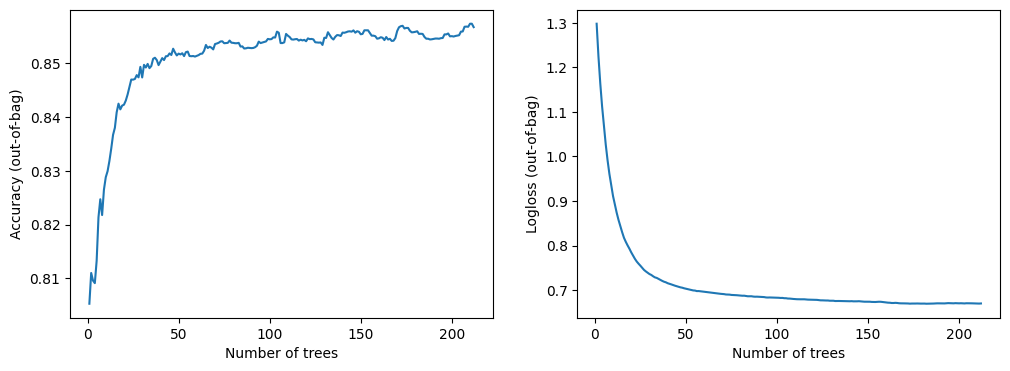

In [40]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [41]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

23/23 [==============================] - 0s 5ms/step
The ROC AUC score is 0.92745


In [42]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

45/45 [==============================] - 0s 5ms/step
Sklearn binary metrics:
accuracy: 0.8768
precision: 0.3235
recall: 0.8160
f1: 0.4633
mcc: 0.4642
roc_auc: 0.9252
pr_auc: 0.6320
log_loss: 0.3031
brier_score: 0.0923

Confusion matrix:
 [[37033  4999]
 [  539  2390]]

Classification report:
               precision    recall  f1-score   support

           0     0.9857    0.8811    0.9304     42032
           1     0.3235    0.8160    0.4633      2929

    accuracy                         0.8768     44961
   macro avg     0.6546    0.8485    0.6968     44961
weighted avg     0.9425    0.8768    0.9000     44961

